In [1]:
print("hellow world")

hellow world


In [2]:
from langgraph.graph import StateGraph ,END ,START

In [3]:
#loop:
#     start -> chat_node -> end

In [6]:
from typing import TypedDict,Annotated

from dotenv import load_dotenv
import langchain_google_genai
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0
)


In [7]:
result = model.invoke("what is the capital of france?")
result

AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'EusCCugCARFNMg9HNJnGHsOLrh34mAh89oDaatAg6YtKprWq2NRppF7wnITySPfX0dMJNtnjR/14GmuJhU0AwgNTIF8SycbygMjYfdJvqr0w4LkQEBfo3ohFxvoLYkbrVjdovvSLfTDCwNQRZG9qnzyZXAHNM8vZhzK1gmqAjibyiBhReyWdgcvBnyXcYJ9UGIqNRRBTphng/M2Qye8Hw2hn6zRgBfeWpGgr0nCN5QxnTPSIY1/g9XpQ/M2M5T3ElgnMWkcUAabqNeaU5RxxH80huA1nCdv+MLHtJNhoIDRJArJkxH88PTDAKOG89wML/mkRrGFUhHiD2hcCt66znSHPmbvYghHsq9Kw9Y2fC9Yin6j6d+Tj6UXtLXNaKQmCfsQHTdvBR6GW5ePZ0LivvUoYtqJyxiA54a9V/VcxIvUl/CyJXKKYQvMD1Qxt2deLCG2r9dkFQ0BnZv8ptx4/sOucAH4TEFMe+aDhkjwO'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00b56-7279-75d1-b7f1-9b6900cad97a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 70, 'total_tokens': 78, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reason

In [15]:
from langchain_core.messages import BaseMessage,HumanMessage
from langgraph.graph import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [34]:
def show_chat_result(result):
    for message in result['messages']:
        print(f"{message.type}: {message.content}")

In [35]:
show_chat_result(result)

human: hi
ai: [{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'Es0FCsoFARFNMg+tpcVDIZ+DtpqsOuawbrEckVwLFeqfOmIEwfQ4nKwh3gnRzWG9doTwMO8gLAEZJnR+aupks9Mh4NlsBc7IT5oeP/Ge8qVL7jt2IKnRcvGDPblrhyVdsMP+BNU+wLRmt/m2CYMSsB/CS5MdVc6Fs06DBjNHOHRihOR1ouhC11OW4n/Ra2CY16wKY1hTwkAdqE9MJMmY1hDARY+g2FLhLhGj7JJDhL0F6J6KbaQFSHusmQnXMy60LaeZwTZtuZAaRed089cvW7Nb81KEx2pB0FwATfKUeEbpnrrA6HKYHSBx6wcM0Xz5FkjO7pGAJHfIYm8Cs6E6aoizSFxJXEczkyJzYITBVF1lBLRojikoxcIuPWu36AZrsvEu7/n1E46xW4q8OUxDvUtrNS1WPEjiDeTfaj8XgPW+CCGdvoJJyuhGYMYSU7c0wvrKvTLL7VRJ5BieypDjIFeRBKg7Wks7us2b42mBleJ987qGirUYRAYGzUqzDQgXG3JzLK43o4GiOoaFSSNIa9Ve0ZpN8FdEiE0hFe18mWxIjsul5sRMl1FsRtbMfn9kIdTTQkv3IMragJrNgDxnlu47dMBMCQMzPExLIbDE3mg3V5/tDB/eOjM0i14ISAxcTfRJXnXQlz1u5pu8FaUkadHqNy4JzNo+I5Gy7D5vZXe/ZcxFImKg1mMTKoNYcHULTfzYKMn9RG8B3NB9/w9W/Z1Ie8PEJ+UCG8OfiwyxXEvPYnfkys4j4T7kZwf5kUYX1GrjLeYVTRs2sF+mfejne7ZWZn472kkmT6wmm1cZtEh6gA2uBqXngmkPoZBn9n71gQqLxZWuafGGX6wxL5anRCuhwpKCJ7t42QITLXOBT8F/draHgn/0cztIn2SdLn9n3ei

In [36]:
def chat_node(state: ChatState) -> ChatState:
    #take user query from state
    messages  = state.get("messages", [])
    #send to llm
    result = model.invoke(messages)
    #response store state
    return {'messages':[result]}

In [42]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)
#add nodes 
graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

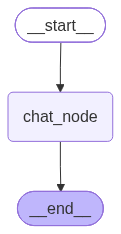

In [43]:
chatbot


In [44]:
initial_state={
    'messages': [HumanMessage(content="what is the capital of france?")]
}

result = chatbot.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'The capital of France is **Paris**.',
  'extras': {'signature': 'EoYDCoMDARFNMg/7/Sm2d/5oLclvIgXsXYIB+x8m/mALwoWm7xW6/GPXMaNcg+6XbnTrjOwvV8d6MIERAR6k9lfHHYrtFPuckwQ9rgl5S673BOhtRSBCRo7BWSYEyYnHDcmbeU/H/lFYDBeW3B9tD+1SVsXjihb0e9LgO2L0GQJX4pSadeSFPSZSCjoHTYemItPvt1OHiFgMDDQQtwqbsCUn2g2KiCJNMvk/tp2yQoREIw5Z3qP0W7y4WY9kINSanRMd+MHu/HoAx5G1ww4sDRrFoIE8Fm4o4E6st7S6K2nAHi7XA7lCnPzH/dECPUnEcWhKsvXP5jYBNXsdQW9da/EuFLmYyCabOz+ndoi5nEDyZGI5kaZH3myiKZtnkUDQSUUP9uc3FYaDAE1H3LgbAZs2rBM3BMVFdxnuNE8RwraqpiOPCvPMvmjCiwpwE+yq6Fwa3TKAgo6Natf9VjNpFzqyrf4ja0sB/ZaZqJAuZW3o0GO+84eFzx+jpW3MVHlrsFe80RYMszJ2'}}]

In [41]:
from langgraph.checkpoint.memory import MemorySaver

In [45]:
thread_id = '1'



while True:
    user_message = input("type your query: ")
    print("\n")
    print("User:", user_message)
    if user_message.strip().lower() in ["exit", "quit","bye"]:
        print("Exiting the chat. Goodbye!")
        break

    config={
        'configurable':{
            'thread_id':thread_id
        }
    }

    initial_state={
        'messages': [HumanMessage(content=user_message)]
    }

    result = chatbot.invoke(initial_state, config=config)

    print("Bot:", result['messages'][-1].content)



User: hi my name is karan
Bot: [{'type': 'text', 'text': "Hello Karan! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'EvAGCu0GARFNMg9EDDh07fAJM+mfNXqK1FI0NYv4wUYyeN8ZIP5hQ/iavpO00rh79K1ol6umhI8I3RSZ8UrnNwLZQhgNdZeVENwsCwPqhu0R8P9zAffe3X7Hqry+2cFRQLDlTme8KMBNB75oz7ANVtZU7WYz6CjRdjhT9ffv70R0tu3SxyD14bK+D7/72PCOVNilwrRPJtpwBSw/3y1ZOuaFSPUK1559ni9IhsDRRYPD4y1ex/PG2c/mpiqI9WM36VOY+BxEPKhUlxirJeqP8LqlADRzIC27R3O0nw04wC6osfAkNZGeD2o3WVMHoi/+2E2H3UTRzItk3w+PT725BYGGqpiJNxooKwjk1szj1eIf8H9fz9Dua5QoJDiyN21BKaWTz6KqlBDW57rQkPXLQSmqEQy8zx/vdifondZ7FEmWunbLv3dnnSMUx5YtQPyunV/3c7nrBungn5QgWpFY3VuvYQirk1fNsOx5XJh1G9vjr/GcccP3ojGNC6f56cLD0mfLbmdUOQiG7Y1AOq5PYrdSKnhXaV/8AXHAyEWvnDKd/XXDk039cjMdB5WAFqIX4H/rkzCXm10hiYuXOgGNoh0aLT/axRDAeWor8q0Fk6zerVmanZ/XTpuYWh7GlLHxe+95NWIHVfnsKMoanxA3jY0g8eLhOqTKaDo+w4UacIcqpxojhbbGMp9yMqugG0fcVGOiqSgETpSyQlw+r8AyH1lfomYEUYIGotMRjWpH9bUNVGgokdwUYW7Hno6M2SfbenpTKTseBZC0lXo94S8Ghmx8936s8jsM5IvF3jEWAQeoTjW+XK1QVIQMw2ya+ilDec6DsfCfMfBA3DXv7TB